# Balancing Data Technique

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [11]:
spam_dataset = pd.read_csv(r"/content/drive/MyDrive/Feature Engineering and ETA/spam.csv", encoding = 'latin')
spam_dataset = spam_dataset[["v1", "v2"]]
spam_dataset.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


The v1 column contains labels or categories for the messages in our dataset. Let’s see how the data is distributed for the different categories. The script below prints the count of messages for each category along with a pie chart depicting the distribution.

In [12]:
print(spam_dataset["v1"].value_counts())

v1
ham     4825
spam     747
Name: count, dtype: int64


<Axes: ylabel='Type'>

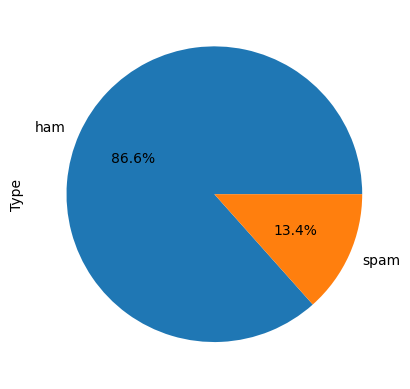

In [13]:
spam_dataset.groupby('v1').size().plot(kind='pie',
                                       y = "v1",
                                       label = "Type",
                                       autopct='%1.1f%%')

From the above output, you can see that there are 4825 ham messages in our dataset, while the number of spam messages is only 747. The pie chart further highlights the imbalanced nature of our dataset where 86.6% of our records belong to the ham category while only 13.4% of our records are spam.

We will be separating the list with hama and spam data

In [14]:
ham_messages = spam_dataset[spam_dataset["v1"] == "ham"]
spam_messages  = spam_dataset[spam_dataset["v1"] == "spam"]
print(ham_messages.shape)
print(spam_messages.shape)

(4825, 2)
(747, 2)


# Downsampling Technique

In [16]:
from sklearn.utils import resample

ham_downsample = resample(ham_messages,
             replace=True,
             n_samples=len(spam_messages),
             random_state=42)

print(ham_downsample.shape)

(747, 2)


Now to create the final sample data set we merge the newly generated ham data set with spam data set

v1
ham     747
spam    747
Name: count, dtype: int64


<Axes: ylabel='Type'>

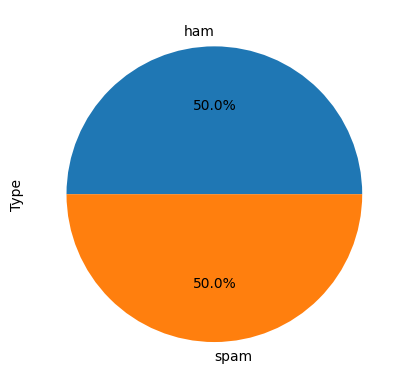

In [17]:
data_downsampled = pd.concat([ham_downsample, spam_messages])

print(data_downsampled["v1"].value_counts())

data_downsampled.groupby('v1').size().plot(kind='pie',
                                       y = "v1",
                                       label = "Type",
                                       autopct='%1.1f%%')

# Upsampling with sklearn

In [18]:
from sklearn.utils import resample
spam_upsample = resample(spam_messages,
             replace=True,
             n_samples=len(ham_messages),
             random_state=42)

print(spam_upsample.shape)

(4825, 2)


v1
ham     4825
spam    4825
Name: count, dtype: int64


<Axes: ylabel='Type'>

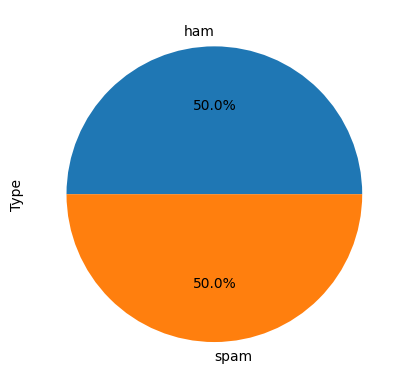

In [19]:
data_upsampled = pd.concat([ham_messages, spam_upsample])

print(data_upsampled["v1"].value_counts())

data_upsampled.groupby('v1').size().plot(kind='pie',
                                       y = "v1",
                                       label = "Type",
                                       autopct='%1.1f%%')